# Model comparison

In [1]:
import os
import numpy as np
import pandas as pd
from scipy.stats import ttest_rel, sem
from matplotlib import pyplot as plt
import seaborn as sns
from my_fun import fig_size, add_star_between, get_experiment, filter_drug_sessions
from pathlib import Path
from glue_sessions.glue_sessions import glue_animals, glue_groups
from glmhmm import *
import ast

In [2]:
# Magics
%load_ext autoreload
%autoreload 2

## Load null model (Bernoulli coin-flip)

In [3]:
# df_1s_null = fit_all(experiments=['2AFC_2', '2AFC_3', '2AFC_4', '2AFC_6'], n_states=1, covariates=['bias'], drug=None, save=True)
df_1s_null = glue_groups(experiments=['2AFC_2', '2AFC_3', '2AFC_4'], path_session='glmhmm/TEST/1s_null')
ll_null = df_1s_null['LogLikelihood'].unique()
n_trials = df_1s_null.groupby('Subject').size()

## 1 covariate (stimulus)

In [ ]:
df_1s_1cov = glue_groups(experiments=['2AFC_2', '2AFC_3', '2AFC_4'], path_session='glmhmm/TEST/1s_1cov')
df_2s_1cov = glue_groups(experiments=['2AFC_2', '2AFC_3', '2AFC_4'], path_session='glmhmm/TEST/2s_1cov')
# df_3s_1cov = glue_groups(experiments=['2AFC_2', '2AFC_3', '2AFC_4'], path_session='glmhmm/TEST/3s_1cov')
df_4s_1cov = glue_groups(experiments=['2AFC_2', '2AFC_3', '2AFC_4'], path_session='glmhmm/TEST/4s_1cov')
df_5s_1cov = glue_groups(experiments=['2AFC_2', '2AFC_3', '2AFC_4'], path_session='glmhmm/TEST/5s_1cov')

figsize = fig_size(n_cols=2)
figsize = (figsize[0], figsize[1]*2)
plt.figure(figsize=figsize, constrained_layout=True)

ll_1 = df_1s_1cov['LogLikelihood'].unique()
ll_2 = df_2s_1cov['LogLikelihood'].unique()
# ll_3 = df_3s_1cov['LogLikelihood'].unique()
ll_4 = df_4s_1cov['LogLikelihood'].unique()
ll_5 = df_5s_1cov['LogLikelihood'].unique()

n_trials_1 = df_1s_1cov.groupby('Subject').size()
n_trials_2 = df_2s_1cov.groupby('Subject').size()
# n_trials_3 = df_3s_1cov.groupby('Subject').size()
n_trials_4 = df_4s_1cov.groupby('Subject').size()
n_trials_5 = df_5s_1cov.groupby('Subject').size()

ll_1 = plot_ll(ll_1, n_trials_1, to_bits=True, positions=[1])
ll_2 = plot_ll(ll_2, n_trials_2, to_bits=True, positions=[2])
# ll_3 = plot_ll(ll_3, n_trials_3, to_bits=True, positions=[3])
ll_4 = plot_ll(ll_4, n_trials_4, to_bits=True, positions=[4])
ll_5 = plot_ll(ll_5, n_trials_5, to_bits=True, positions=[5])

ll_1 = np.array(ll_1)
ll_2 = np.array(ll_2)
ll_3 = np.array(ll_3)
ll_4 = np.array(ll_4)
ll_5 = np.array(ll_5)

inliers_1 = iqr_inliers(ll_1)
inliers_2 = iqr_inliers(ll_2)
inliers_3 = iqr_inliers(ll_3)
inliers_4 = iqr_inliers(ll_4)
inliers_5 = iqr_inliers(ll_5)

# for y0, y1 in zip(ll0, ll1):
#     plt.plot([0, 1], [y0, y1], color='k', alpha=0.1)
mask = inliers_1 & inliers_2 & inliers_3 & inliers_4 & inliers_5
for y1, y2 in zip(ll_1[mask], ll_2[mask]):
    plt.plot([1, 2], [y1, y2], color='k', alpha=0.1)
for y2, y3 in zip(ll_2[mask], ll_3[mask]):
    plt.plot([2, 3], [y2, y3], color='k', alpha=0.1)
for y3, y4 in zip(ll_3[mask], ll_4[mask]):
    plt.plot([3, 4], [y3, y4], color='k', alpha=0.1)
for y4, y5 in zip(ll_4[mask], ll_5[mask]):
    plt.plot([4, 5], [y4, y5], color='k', alpha=0.1)

# Paired t-test between states (not needed because sums to 1)
t_stat, p_val = ttest_rel(ll_1, ll_2)
print(f't = {t_stat:.3f}, p = {p_val:.3f}')
add_star_between(p_val, 1, 2)
t_stat, p_val = ttest_rel(ll_2, ll_3)
print(f't = {t_stat:.3f}, p = {p_val:.3f}')
add_star_between(p_val, 2, 3)
t_stat, p_val = ttest_rel(ll_3, ll_4)
print(f't = {t_stat:.3f}, p = {p_val:.3f}')
add_star_between(p_val, 3, 4)
t_stat, p_val = ttest_rel(ll_4, ll_5)
print(f't = {t_stat:.3f}, p = {p_val:.3f}')
add_star_between(p_val, 4, 5)

plt.xticks([1, 2, 3, 4, 5], ['1', '2', '3', '4', '5'])
plt.xlabel('N states')
plt.title('2 Covariates\n(stim. and bias)')
sns.despine()

ll_1_cov_means = [np.mean(ll_1), np.mean(ll_2), np.mean(ll_3), np.mean(ll_4), np.mean(ll_5)]

## 2 covariates (stim and bias)

Loading results of model with 1 states and 2 covariates
0.30 ± 0.32 LL (bits/trial)
Loading results of model with 2 states and 2 covariates
0.39 ± 0.33 LL (bits/trial)
Loading results of model with 3 states and 2 covariates
0.43 ± 0.35 LL (bits/trial)
Loading results of model with 4 states and 2 covariates
0.45 ± 0.35 LL (bits/trial)
Loading results of model with 5 states and 2 covariates
0.46 ± 0.37 LL (bits/trial)
t = -9.531, p = 0.000
t = -8.759, p = 0.000
t = -6.533, p = 0.000
t = -5.524, p = 0.000


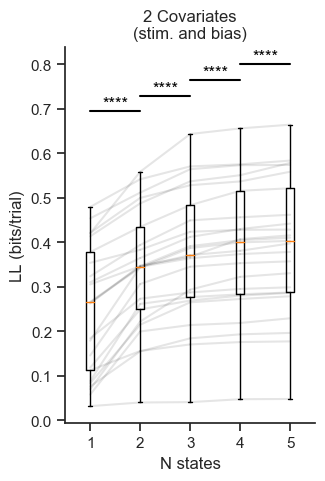

In [47]:
lls_2cov = plot_model_comparison(n_cov=2, ll_null=ll_null, fit=False)

## 3 covariates  (stimulus, bias, and action trace)

Loading results of model with 1 states and 3 covariates
0.38 ± 0.33 LL (bits/trial)
Loading results of model with 2 states and 3 covariates
0.44 ± 0.35 LL (bits/trial)
Loading results of model with 3 states and 3 covariates
0.45 ± 0.37 LL (bits/trial)
Loading results of model with 4 states and 3 covariates
0.47 ± 0.37 LL (bits/trial)
Loading results of model with 5 states and 3 covariates
0.47 ± 0.37 LL (bits/trial)
t = -10.721, p = 0.000
t = -4.540, p = 0.000
t = -5.328, p = 0.000
t = -4.238, p = 0.000


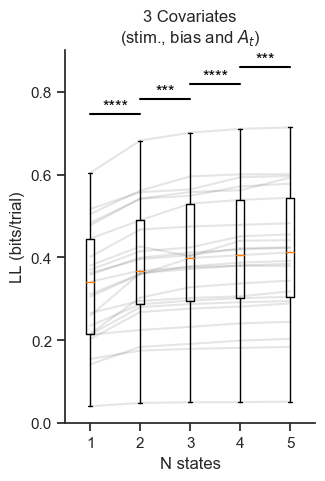

In [92]:
lls_3cov = plot_model_comparison(n_cov=3, ll_null=ll_null, fit=False)

## 4 covariates  (stimulus, bias, At- and At+)

Loading results of model with 1 states and 4 covariates
0.39 ± 0.33 LL (bits/trial)
Loading results of model with 2 states and 4 covariates
0.44 ± 0.35 LL (bits/trial)
Loading results of model with 3 states and 4 covariates
0.46 ± 0.37 LL (bits/trial)
Loading results of model with 4 states and 4 covariates
0.47 ± 0.37 LL (bits/trial)
Loading results of model with 5 states and 4 covariates
0.47 ± 0.38 LL (bits/trial)
t = -11.649, p = 0.000
t = -4.861, p = 0.000
t = -5.843, p = 0.000
t = -3.614, p = 0.001


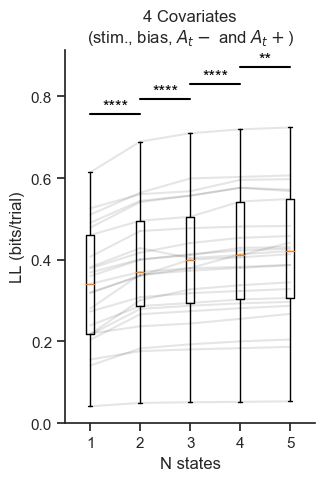

In [93]:
lls_4cov = plot_model_comparison(n_cov=4, ll_null=ll_null, fit=False)

## LL per state

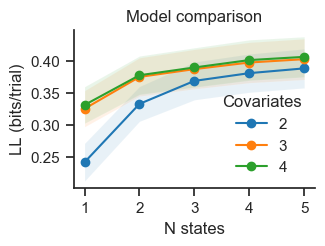

In [75]:
# Remove outliers based on IQR
inliers_2cov = [iqr_inliers(ll) for ll in lls_2cov]
inliers_3cov = [iqr_inliers(ll) for ll in lls_3cov]
inliers_4cov = [iqr_inliers(ll) for ll in lls_4cov]
lls_2cov = [ll[inliers] for ll, inliers in zip(lls_2cov, inliers_2cov)]
lls_3cov = [ll[inliers] for ll, inliers in zip(lls_3cov, inliers_3cov)]
lls_4cov = [ll[inliers] for ll, inliers in zip(lls_4cov, inliers_4cov)]

# Compute mean and sem LL per state (across subjects) for each model
means_2cov = [ll.mean() for ll in lls_2cov]
means_3cov = [ll.mean() for ll in lls_3cov]
means_4cov = [ll.mean() for ll in lls_4cov]
sems_2cov = [sem(ll) for ll in lls_2cov]
sems_3cov = [sem(ll) for ll in lls_3cov]
sems_4cov = [sem(ll) for ll in lls_4cov]

figsize = fig_size(n_cols=2)
plt.figure(figsize=figsize, constrained_layout=True)

# Plot all curves in one figure
plt.plot(means_2cov, marker='o', label='2')
plt.fill_between(range(5), np.array(means_2cov)-np.array(sems_2cov),
                 np.array(means_2cov)+np.array(sems_2cov), alpha=0.1)
plt.plot(means_3cov, marker='o', label='3')
plt.fill_between(range(5), np.array(means_3cov)-np.array(sems_3cov),
                 np.array(means_3cov)+np.array(sems_3cov), alpha=0.1)
plt.plot(means_4cov, marker='o', label='4')
plt.fill_between(range(5), np.array(means_4cov)-np.array(sems_4cov),
                 np.array(means_4cov)+np.array(sems_4cov), alpha=0.1)

plt.xticks(range(5), ['1', '2', '3', '4', '5'])  # N states
plt.xlabel('N states')
plt.ylabel('LL (bits/trial)')
plt.title('Model comparison')
plt.legend(title='Covariates', frameon=False)
sns.despine()

From the model comparison, the best models are 2 states with 3 covariates and 3 states with 2 covariates. Let's compare them directly.

# Final match: 2 states and 3 covariates VS 3 states and 2 covariates

## Log likelihood

0.44 ± 0.35 LL (bits/trial)
0.43 ± 0.35 LL (bits/trial)
t = 2.200, p = 0.038


(-0.05, 0.05)

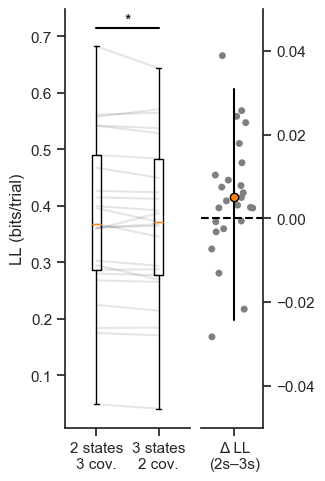

In [105]:
df_2s_3cov = glue_groups(experiments=['2AFC_2', '2AFC_3', '2AFC_4'], path_session=f'glmhmm/TEST/2s_3cov')
df_3s_2cov = glue_groups(experiments=['2AFC_2', '2AFC_3', '2AFC_4'], path_session=f'glmhmm/TEST/3s_2cov')

ll_2s_3cov = df_2s_3cov['LogLikelihood'].unique()
ll_3s_2cov = df_3s_2cov['LogLikelihood'].unique()
n_trials = df_2s_3cov.groupby('Subject').size()
n_trials = df_3s_2cov.groupby('Subject').size()

figsize = fig_size(n_cols=2)
figsize = (figsize[0], figsize[1] * 2)
fig, axes = plt.subplots(1, 2, figsize=figsize, constrained_layout=True, gridspec_kw={'width_ratios': [2, 1]})
ax_left, ax_right = axes
plt.sca(ax_left)
# plt.figure(figsize=figsize, constrained_layout=True)

ll_2s_3cov = plot_ll(ll_2s_3cov, n_trials, ll_null, to_bits=True, positions=[1])
ll_3s_2cov = plot_ll(ll_3s_2cov, n_trials, ll_null, to_bits=True, positions=[2])
plt.xticks([1, 2] , ['2 states\n3 cov.', '3 states\n2 cov.'])
plt.xlabel('')

ll_2s_3cov = np.array(ll_2s_3cov)
ll_3s_2cov = np.array(ll_3s_2cov)
lls = [ll_2s_3cov, ll_3s_2cov]

inliers_2s_3cov = iqr_inliers(ll_2s_3cov)
inliers_3s_2cov = iqr_inliers(ll_3s_2cov)
inliers = [inliers_2s_3cov, inliers_3s_2cov]
mask = np.logical_and.reduce(inliers)  # Reuse for later

for i in range(len(lls) - 1):
    for y_prev, y_next in zip(lls[i][mask], lls[i + 1][mask]):
        plt.plot([i + 1, i + 2], [y_prev, y_next], color='k', alpha=0.1)
    t_stat, p_val = ttest_rel(lls[i][mask], lls[i + 1][mask])
    print(f't = {t_stat:.3f}, p = {p_val:.3f}')
    add_star_between(p_val, i + 1, i + 2)

# Compute paired differences
diff =  ll_2s_3cov - ll_3s_2cov
plt.sca(ax_right)
sns.stripplot(y=diff, color='tab:gray', ax=ax_right, zorder=1)
mean_diff = diff.mean()
ci_low, ci_high = np.percentile(diff, [2.5, 97.5])
plt.plot([0, 0], [ci_low, ci_high], color='k', zorder=2)
plt.scatter(0, mean_diff, facecolor='tab:orange', edgecolor='k', zorder=3)
plt.axhline(0, color='k', ls='--')

plt.xticks([0], ['Δ LL\n(2s–3s)'])
# plt.ylabel('Δ LL (bits/trial)')
ax_right.yaxis.tick_right()
ax_right.yaxis.set_label_position('right')
ax_right.spines['top'].set_visible(False)
ax_right.spines['left'].set_visible(False)
ax_right.spines['right'].set_visible(True)
ax_right.set_ylim(-0.05, 0.05)

## Weights

In [107]:
def plot_kernel(df):
    # Convert weights from strings back to arrays
    # (pandas stores them as strings when writting to csv)
    n_states = df.Nstates.unique()[0]
    input_dim = df.InputDimensions.unique()[0]
    weights = df.Weights.unique()  # Get unique strings

    # Convert all strings to arrays
    weights = np.array([
        np.fromstring(s.replace('\n','').strip('[]'), sep=' ').reshape(n_states, input_dim)
        for s in weights
    ])

    weights = weights.reshape(weights.shape[0], -1)  # Flatten 2D arrays to 1D for uniqueness check
    weights = np.unique(weights, axis=0)  # Get unique arrays
    weights = weights.reshape(-1, n_states, input_dim)  # Reshape back to 2D arrays
    # weights = weights[mask]  # Keep only inliers based on LL

    # Remove outliers based on IQR for each covariate (for zooming in plots)
    n_animals, n_states, n_cov = weights.shape
    mask = np.ones(n_animals, dtype=bool)  # Initialize mask with all True
    for i_state in range(n_states):
        for j_cov in range(n_cov):
            inliers = iqr_inliers(weights[:, i_state, j_cov])
            mask &= inliers  # keep only animals that are inliers for all covariates
    print(f'Kept {mask.sum()} / {n_animals} subjects after column-wise IQR filtering')
    weights = weights[mask]


    # Plot weights
    mean_weights = weights.mean(axis=0)
    sem_weights = sem(weights, axis=0)

    # Plot each state's mean kernel
    if n_states == 2 and input_dim == 3:
        state_labels = ['Disengaged', 'Engaged']
        colors = ['tab:gray', 'tab:green']
        cov_labels = ['Stim.', 'Bias', r'$A_t$']
        title = '2 states 3 covariates'
    elif n_states == 3 and input_dim == 2:
        state_labels = ['Engaged', 'Left bias', 'Right bias']
        colors = ['tab:green', 'tab:blue', 'tab:orange']
        cov_labels = ['Stim.', 'Bias']
        title = '3 states 2 covariates'

    x = np.arange(len(cov_labels))

    figsize = fig_size(n_cols=2)
    plt.figure(figsize=figsize, constrained_layout=True)
    plt.axhline(y=0, color='k', ls='--')

    # Individuals
    for w in weights:  # w shape: (n_states, n_cov)
        for s in range(n_states):
            plt.plot(x, w[s], color=colors[s % len(colors)], alpha=0.1)

    # Mean ± SEM
    for s in range(n_states):
        plt.errorbar(
            x, mean_weights[s], yerr=sem_weights[s],
            marker='o', lw=3, color=colors[s % len(colors)],
            label=state_labels[s]
        )

    plt.xticks(x, cov_labels)
    # plt.xlabel('Covariates')
    plt.ylabel('Weights')
    plt.title(title)
    plt.legend(frameon=False)
    sns.despine()

Kept 20 / 25 subjects after column-wise IQR filtering
Kept 17 / 25 subjects after column-wise IQR filtering


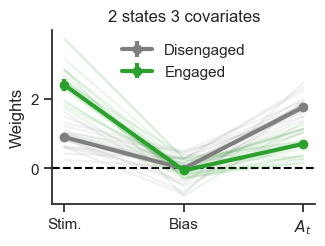

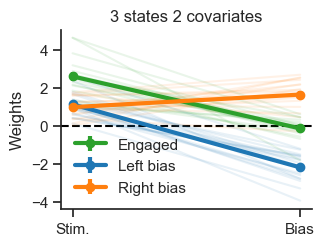

In [108]:
plot_kernel(df_2s_3cov)
plot_kernel(df_3s_2cov)

## P(engaged)

# Occupancy

In [ ]:
occ_2s_2cov_saline = plot_occupancy_boxplot(df_2s_2cov[df_2s_2cov.Drug==0], figsize=figsize)
occ_2s_2cov_drug = plot_occupancy_boxplot(df_2s_2cov[df_2s_2cov.Drug==1], figsize=figsize)
occ_2s_2cov_saline['Drug'] = 0
occ_2s_2cov_drug['Drug'] = 1
occ_2s_2cov_comparison = pd.concat([occ_2s_2cov_saline, occ_2s_2cov_drug], ignore_index=True)
plt.figure(figsize=figsize, constrained_layout=True)
sns.boxplot(data=occ_2s_2cov_comparison, x='Drug', y='Engaged', palette=['tab:gray','tab:pink'], showfliers=False)
# Paired t-test between states (not needed because sums to 1)
engaged_saline = occ_2s_2cov_comparison[occ_2s_2cov_comparison['Drug'] == 0]['Engaged']
engaged_drug = occ_2s_2cov_comparison[occ_2s_2cov_comparison['Drug'] == 1]['Engaged']
t_stat, p_val = ttest_rel(engaged_saline, engaged_drug)
print(f't = {t_stat:.3f}, p = {p_val:.3f}')
add_star_between(p_val, 0, 1)
plt.xticks([0,1], ['Saline','Drug'])
plt.ylim(0, 1)
plt.xlabel('Engaged')
plt.ylabel('Occupancy')
sns.despine()
plt.title('2 states\n(2 cov.: stim., bias)')



occ_2s_3cov_saline = plot_occupancy_boxplot(df_2s_3cov[df_2s_3cov.Drug==0], figsize=figsize)
occ_2s_3cov_drug = plot_occupancy_boxplot(df_2s_3cov[df_2s_3cov.Drug==1], figsize=figsize)
occ_2s_3cov_saline['Drug'] = 0
occ_2s_3cov_drug['Drug'] = 1
occ_2s_3cov_comparison = pd.concat([occ_2s_3cov_saline, occ_2s_3cov_drug], ignore_index=True)
plt.figure(figsize=figsize, constrained_layout=True)
sns.boxplot(data=occ_2s_3cov_comparison, x='Drug', y='Engaged', palette=['tab:gray','tab:pink'], showfliers=False)
# Paired t-test between states (not needed because sums to 1)
engaged_saline = occ_2s_3cov_comparison[occ_2s_3cov_comparison['Drug'] == 0]['Engaged']
engaged_drug = occ_2s_3cov_comparison[occ_2s_3cov_comparison['Drug'] == 1]['Engaged']
t_stat, p_val = ttest_rel(engaged_saline, engaged_drug)
print(f't = {t_stat:.3f}, p = {p_val:.3f}')
add_star_between(p_val, 0, 1)
plt.xticks([0,1], ['Saline','Drug'])
plt.ylim(0, 1)
plt.xlabel('Engaged')
plt.ylabel('Occupancy')
sns.despine()
plt.title('2 states\n(3 cov.: stim., bias, At)')



occ_3s_2cov_saline = plot_occupancy_boxplot(df_3s_2cov[df_3s_2cov.Drug==0], figsize=figsize)
occ_3s_2cov_drug = plot_occupancy_boxplot(df_3s_2cov[df_3s_2cov.Drug==1], figsize=figsize)
occ_3s_2cov_saline['Drug'] = 0
occ_3s_2cov_drug['Drug'] = 1
occ_3s_2cov_comparison = pd.concat([occ_3s_2cov_saline, occ_3s_2cov_drug], ignore_index=True)
plt.figure(figsize=figsize, constrained_layout=True)
sns.boxplot(data=occ_3s_2cov_comparison, x='Drug', y='Engaged', palette=['tab:gray','tab:pink'], showfliers=False)
# Paired t-test between states (not needed because sums to 1)
engaged_saline = occ_3s_2cov_comparison[occ_3s_2cov_comparison['Drug'] == 0]['Engaged']
engaged_drug = occ_3s_2cov_comparison[occ_3s_2cov_comparison['Drug'] == 1]['Engaged']
t_stat, p_val = ttest_rel(engaged_saline, engaged_drug)
print(f't = {t_stat:.3f}, p = {p_val:.3f}')
add_star_between(p_val, 0, 1)
plt.xticks([0,1], ['Saline','Drug'])
plt.ylim(0, 1)
plt.xlabel('Engaged')
plt.ylabel('Occupancy')
sns.despine()
plt.title('3 states\n(2 cov.: stim., bias)')



occ_3s_3cov_saline = plot_occupancy_boxplot(df_3s_3cov[df_3s_3cov.Drug==0], figsize=figsize)
occ_3s_3cov_drug = plot_occupancy_boxplot(df_3s_3cov[df_3s_3cov.Drug==1], figsize=figsize)
occ_3s_3cov_saline['Drug'] = 0
occ_3s_3cov_drug['Drug'] = 1
occ_3s_3cov_comparison = pd.concat([occ_3s_3cov_saline, occ_3s_3cov_drug], ignore_index=True)
plt.figure(figsize=figsize, constrained_layout=True)
sns.boxplot(data=occ_3s_3cov_comparison, x='Drug', y='Engaged', palette=['tab:gray','tab:pink'], showfliers=False)
# Paired t-test between states (not needed because sums to 1)
engaged_saline = occ_3s_3cov_comparison[occ_3s_3cov_comparison['Drug'] == 0]['Engaged']
engaged_drug = occ_3s_3cov_comparison[occ_3s_3cov_comparison['Drug'] == 1]['Engaged']
t_stat, p_val = ttest_rel(engaged_saline, engaged_drug)
print(f't = {t_stat:.3f}, p = {p_val:.3f}')
add_star_between(p_val, 0, 1)
plt.xticks([0,1], ['Saline','Drug'])
plt.ylim(0, 1)
plt.xlabel('Engaged')
plt.ylabel('Occupancy')
sns.despine()
plt.title('3 states\n(3 cov.: stim., bias, At)')

# Playground
Manually fix weights

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import os
import pandas as pd
import numpy as np
import numpy.random as npr
import matplotlib.pyplot as plt
import seaborn as sns
import ssm
from scipy.special import expit as logistic
from matplotlib.lines import Line2D

from glmhmm import *

# Plotting style
default_figsize = np.array(plt.rcParams['figure.figsize'])
# sns.set_theme()
sns.set_style('ticks')
sns.set_context('poster')
style_path = os.path.expanduser('~/PycharmProjects/alexis_style.mplstyle')
plt.style.use(style_path)
%config InlineBackend.figure_format = 'retina'

# Set the parameters of the GLM-HMM
n_states = 2        # Number of discrete states (from Ashwood et al. 2020)
obs_dim = 1         # Number of observed dimensions (1 for binary choice)
n_categories = 2    # Number of categories for output (2 for binary choice)
input_dim = 2       # Input dimensions (stimulus and bias)

glmhmm = ssm.HMM(n_states, obs_dim, input_dim, observations='input_driven_obs',
                   observation_kwargs=dict(C=n_categories), transitions='standard')

# Load data from example mouse
try:
    df = pd.read_csv(r'C:\Users\Usuario\PycharmProjects\glue_sessions\2AFC_2\333.csv')  # Ephys PC
except FileNotFoundError:
    df = pd.read_csv('/home/alexis/PycharmProjects/glue_sessions/2AFC_2/333.csv')  # Cluster

# Filters for groups 1-3
df = df[df.Stage == 4].reset_index(drop=True)
df = df[df.Motor == 4].reset_index(drop=True)
# df = df[df.StimDur == 1].reset_index(drop=True)
df = df[df.P > 0].reset_index(drop=True)

# Drop misses (Choice == NaN)
df = df.dropna(subset=['Choice']).reset_index(drop=True)

covariates = ['stim_vals', 'bias']
state_label_map = {0: 'Lapse', 1: 'Engaged'}

inputs, choices = parse_glmhmm(df, covariates=covariates)

# Fitting with stop earlier if increase in LL is below tolerance specified by tolerance parameter
method = 'em'  # Expectation Maximization method
num_iters = 200 # Max number of EM iterations
tolerance = 1e-4  # Tolerance for stopping criterion
# fit_ll = glmhmm.fit(choices, inputs=inputs, method=method, num_iters=num_iters, tolerance=tolerance)

def enforce_lapse_constraint(hmm, lapse_state=1, stim_index=0):
    hmm.observations.params[lapse_state, 0, stim_index] = 0.0

N_iters = 200
lls = []

# from tqdm import trange
# pbar = trange(N_iters, desc='Fitting lapse GLM-HMM')

for _ in range(N_iters):
    ll = glmhmm.fit(
        choices,
        inputs=inputs,
        method='em',
        num_iters=1,
        initialize=(_ == 0)
    )
    print(f'EM Iteration {_+1}: Log Likelihood = {ll[-1]}')
    # ll = glmhmm.em_step(choices, inputs=inputs)  # Not implemented?
    enforce_lapse_constraint(glmhmm)
    lls.append(ll[-1])
    if _ > 1 and abs(lls[-1] - lls[-2]) < tolerance:
        break

In [ ]:
ll = glmhmm.log_likelihood(choices, inputs=inputs)
n_trials = len(df)
ll = ll / n_trials
ll = ll / np.log(2)
ll_lapse = ll
print(ll_lapse)

In [ ]:
plt.plot(lls, marker='o')
plt.xticks(np.arange(5), ['1','2','3','4','5'])

In [ ]:
plt.plot(lls, marker='o')
plt.xticks(np.arange(6), ['1', 'L', '2','3','4','5'])
plt.xlabel('N states')
plt.ylabel('Mean LL per trial (bits)')
plt.title('Model comparison')
sns.despine()